In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import shutil
from PIL import Image
import joblib
import math

from keras.utils import to_categorical
from keras.preprocessing import image
from keras.applications import VGG16
from keras.models import Model
from keras.layers import Input, Dense, Flatten, concatenate
from keras.optimizers import Adam
from keras.preprocessing import image as keras_image
from keras.regularizers import l2

from skimage import io
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.morphology import label
from skimage.measure import regionprops
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage import morphology
from skimage.io import imread
from skimage.transform import resize
from skimage import io, color, filters, morphology, transform

from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, concatenate,Concatenate
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import concatenate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [6]:
df = "C:\\Users\\Tracy Khor\\Desktop\\CAMPUS\\FYP\\Dataset\\Final_ISIC - Copy.csv"
base_path = 'C:\\Users\\Tracy Khor\\Desktop\\CAMPUS\\FYP\\Dataset\\removed_border'

In [7]:
df = pd.read_csv(df)

In [8]:
print(df.isnull().sum())

image                  0
age_approx             0
anatom_site_general    0
sex                    0
Target                 0
dtype: int64


In [9]:
print(df.describe())

         age_approx  anatom_site_general           sex        Target
count  25276.000000         25276.000000  25276.000000  25276.000000
mean      54.042570             1.946194      0.533194      1.568484
std       17.976224             1.937141      0.498907      1.532974
min        0.000000             0.000000      0.000000      0.000000
25%       40.000000             0.000000      0.000000      1.000000
50%       55.000000             2.000000      1.000000      1.000000
75%       70.000000             3.000000      1.000000      2.000000
max       85.000000             7.000000      1.000000      7.000000


In [10]:
print(df.shape)

(25276, 5)


In [11]:
# Check the first few rows of train_df
print(df.head())

# Check the column names of train_df
print(df.columns)


          image  age_approx  anatom_site_general  sex  Target
0  ISIC_0000000          55                    0    0       1
1  ISIC_0000001          30                    0    0       1
2  ISIC_0000002          60                    1    0       0
3  ISIC_0000003          30                    1    1       1
4  ISIC_0000004          80                    2    1       0
Index(['image', 'age_approx', 'anatom_site_general', 'sex', 'Target'], dtype='object')


In [12]:
train_idx, val_idx = train_test_split(df.index, test_size=0.2, random_state=42)

train_df = df.loc[train_idx]
val_df = df.loc[val_idx]

encoder = OneHotEncoder(sparse_output=False) 
encoder.fit(df[['anatom_site_general', 'sex']])

def encode_features(df, encoder):
    numerical_features = df[['age_approx']].values
    categorical_features = encoder.transform(df[['anatom_site_general', 'sex']])
    return np.concatenate([numerical_features, categorical_features], axis=1)

# Prepare training and validation features
X_additional_train = encode_features(train_df, encoder)
X_additional_val = encode_features(val_df, encoder)

def load_and_preprocess_images(df, base_path):
    X_image = []
    for image_name in df['image']:
        image_path = os.path.join(base_path, image_name + '.jpg')
        if os.path.exists(image_path):
            img = load_img(image_path, target_size=(224, 224))
            img = img_to_array(img)
            img /= 255.0  # Normalize the image
            X_image.append(img)
        else:
            print(f"File {image_path} not found.")
    if len(X_image) == 0:
        raise ValueError("No images were loaded.")
    return np.array(X_image)

X_image_train = load_and_preprocess_images(train_df, base_path)
X_image_val = load_and_preprocess_images(val_df, base_path)

# Convert target labels to one-hot encoded vectors
num_classes = 8  # 8 skin lesion types
y_train_one_hot = to_categorical(train_df['Target'], num_classes=num_classes)
y_val_one_hot = to_categorical(val_df['Target'], num_classes=num_classes)

# Image input layer
image_input = Input(shape=(224, 224, 3))

# Additional features input layer
num_additional_features = X_additional_train.shape[1]
additional_features_input = Input(shape=(num_additional_features,))

# VGG16 model, with the top layers unfrozen as needed
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=image_input)
for layer in base_model.layers[-4:]: 
    layer.trainable = True

image_features = Flatten()(base_model.output)

# Concatenate image features with additional features
combined_features = Concatenate()([image_features, additional_features_input])

x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(combined_features)
x = Dropout(0.5)(x)

# Output layer
output = Dense(num_classes, activation='softmax')(x)

# Define the complete model
model = Model(inputs=[image_input, additional_features_input], outputs=output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [13]:
model.fit([X_image_train, X_additional_train], 
          y_train_one_hot,
          validation_data=([X_image_val, X_additional_val], 
                           y_val_one_hot), 
          epochs=10, 
          batch_size=32)


Epoch 1/10
632/632 [==============================] - 8859s 14s/step - loss: 1.4466 - accuracy: 0.5789 - val_loss: 1.1237 - val_accuracy: 0.6390
Epoch 2/10
632/632 [==============================] - 8965s 14s/step - loss: 1.0928 - accuracy: 0.6426 - val_loss: 0.9861 - val_accuracy: 0.6628
Epoch 3/10
632/632 [==============================] - 8886s 14s/step - loss: 0.9922 - accuracy: 0.6635 - val_loss: 0.9354 - val_accuracy: 0.6808
Epoch 4/10
632/632 [==============================] - 9248s 15s/step - loss: 0.9207 - accuracy: 0.6878 - val_loss: 0.8852 - val_accuracy: 0.6865
Epoch 5/10
632/632 [==============================] - 9732s 15s/step - loss: 0.8533 - accuracy: 0.7035 - val_loss: 0.8226 - val_accuracy: 0.7241
Epoch 6/10
632/632 [==============================] - 9472s 15s/step - loss: 0.8024 - accuracy: 0.7221 - val_loss: 0.8088 - val_accuracy: 0.7182
Epoch 7/10
632/632 [==============================] - 9583s 15s/step - loss: 0.7526 - accuracy: 0.7388 - val_loss: 0.7747 - val_ac

In [14]:
# # Train the model with both image data and additional features
# model.fit([X_image_train, X_num_features_train[:, 0], X_num_features_train[:, 1], X_num_features_train[:, 2]], 
#           y_train_one_hot, 
#           epochs=10, 
#           batch_size=32, 
#           validation_data=([X_image_val, X_num_features_val[:, 0], X_num_features_val[:, 1], X_num_features_val[:, 2]], 
#                            y_val_one_hot))

In [15]:
X_image_val = load_and_preprocess_images(val_df, base_path)
X_additional_val = encode_features(val_df, encoder)
y_pred = model.predict([X_image_val, X_additional_val], batch_size=32)  
y_pred_classes = np.argmax(y_pred, axis=1)
y_val_classes = np.argmax(y_val_one_hot, axis=1)

158/158 [==============================] - 591s 4s/step


In [16]:
try:
    # Convert Keras model to TensorFlow Lite
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()

    # Save the TensorFlow Lite model to the desktop folder
    tflite_model_path = "C:\\Users\\Tracy Khor\\Desktop\\CAMPUS\\FYP\\skin_lesion_modelv8.tflite"

    with open(tflite_model_path, 'wb') as f:
        f.write(tflite_model)

    print("Model exported and saved successfully at:", tflite_model_path)

except Exception as e:
    print("An error occurred during model conversion:", e)

INFO:tensorflow:Assets written to: C:\Users\TRACYK~1\AppData\Local\Temp\tmpghc30t70\assets


INFO:tensorflow:Assets written to: C:\Users\TRACYK~1\AppData\Local\Temp\tmpghc30t70\assets


Model exported and saved successfully at: C:\Users\Tracy Khor\Desktop\CAMPUS\FYP\skin_lesion_modelv8.tflite


In [18]:
train_loss, train_accuracy = model.evaluate([X_image_train, X_additional_train], y_train_one_hot)
val_loss, val_accuracy = model.evaluate([X_image_val, X_additional_val], y_val_one_hot)

print("Training Loss:", train_loss)
print("Training Accuracy:", train_accuracy)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)


158/158 [==============================] - 585s 4s/step - loss: 0.7520 - accuracy: 0.7544
Training Loss: 0.473443865776062
Training Accuracy: 0.831355094909668
Validation Loss: 0.7519785761833191
Validation Accuracy: 0.7543512582778931


In [19]:
# Assuming `X_image_train` and `X_additional_train` are not stored in memory and you only have their lengths
print(f"Number of training images: {len(train_df)}")
print(f"Number of additional features per sample: {X_additional_train.shape[1]}")
print(f"Number of classes: {num_classes}")
print(f"Number of training labels: {y_train_one_hot.shape[0]}")


Number of training images: 20220
Number of additional features per sample: 11
Number of classes: 8
Number of training labels: 20220


Accuracy: 0.7543512658227848
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.50      0.59       856
           1       0.84      0.93      0.88      2604
           2       0.65      0.85      0.74       648
           3       0.47      0.19      0.27       180
           4       0.61      0.55      0.58       570
           5       0.40      0.27      0.32        37
           6       0.54      0.89      0.67        44
           7       0.30      0.13      0.18       117

    accuracy                           0.75      5056
   macro avg       0.57      0.54      0.53      5056
weighted avg       0.74      0.75      0.74      5056



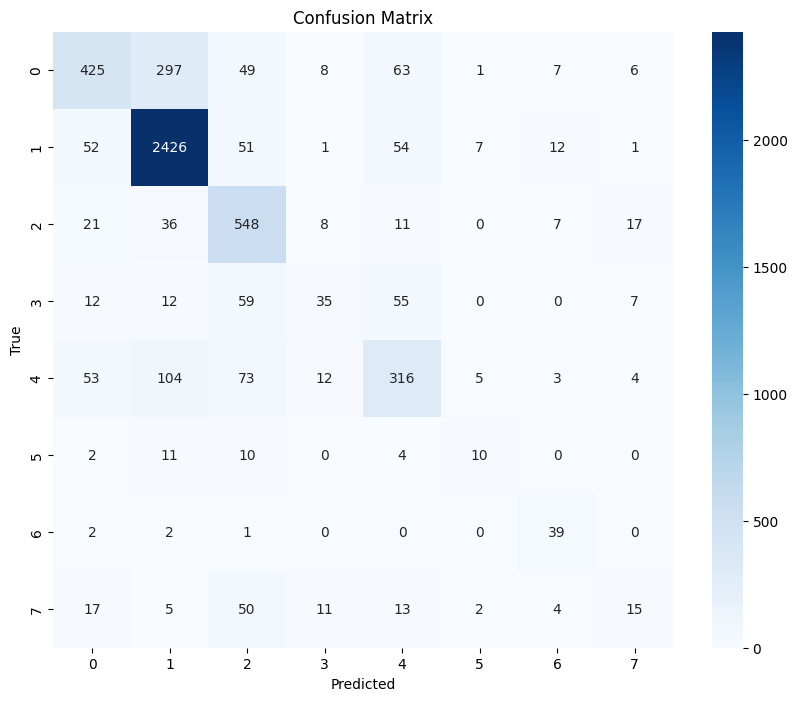

In [17]:
accuracy = accuracy_score(y_val_classes, y_pred_classes)
print(f"Accuracy: {accuracy}")

print("Classification Report:")
print(classification_report(y_val_classes, y_pred_classes))

# Confusion Matrix (if needed)
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

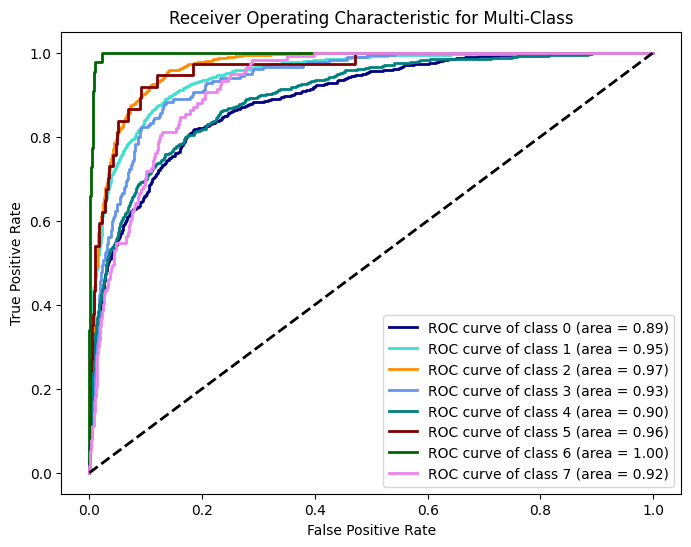

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# ROC Curve
n_classes = 8  

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_one_hot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal', 'maroon', 'darkgreen', 'violet'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-Class')
plt.legend(loc="lower right")
plt.show()

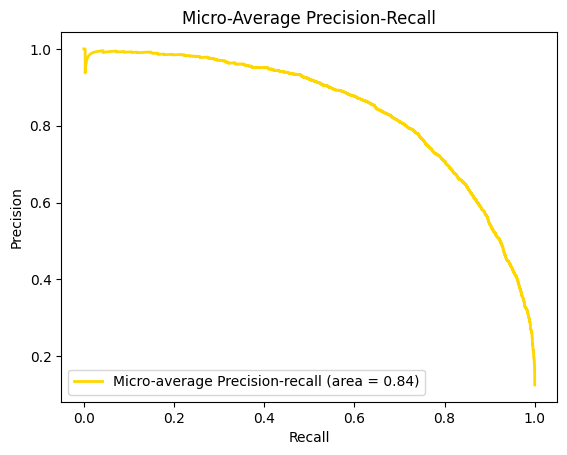

In [24]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision = {}
recall = {}
average_precision = {}
# Compute micro-average precision-recall curve and average precision
precision["micro"], recall["micro"], _ = precision_recall_curve(y_val_one_hot.ravel(), y_pred.ravel())
average_precision["micro"] = average_precision_score(y_val_one_hot, y_pred, average="micro")

# Plotting
plt.figure()
plt.plot(recall["micro"], precision["micro"], color='gold', lw=2,
         label='Micro-average Precision-recall (area = {0:0.2f})'
         ''.format(average_precision["micro"]))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Micro-Average Precision-Recall')
plt.legend(loc="best")
plt.show()
